Shortest path from A to F is: [('E', 'F'), ('D', 'E'), ('B', 'D'), ('C', 'B'), ('A', 'C')]


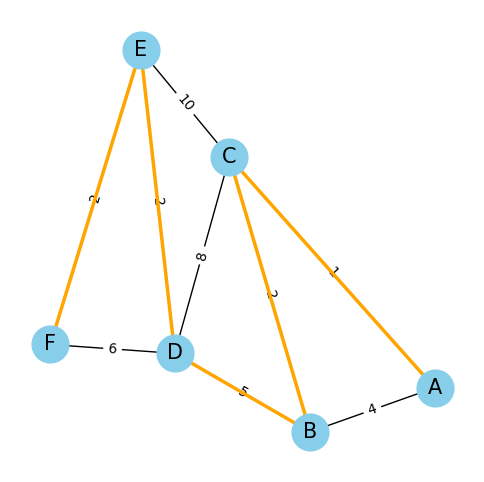

In [3]:
import tkinter as tk
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import time

class DijkstraVisualizer:
    def __init__(self, root):
        self.root = root
        self.root.title("Dijkstra Algorithm Visualization")
        
        # Define the graph as a dictionary of dictionaries with edge weights
        self.graph = {
            'A': {'B': 4, 'C': 1},
            'B': {'A': 4, 'C': 2, 'D': 5},
            'C': {'A': 1, 'B': 2, 'D': 8, 'E': 10},
            'D': {'B': 5, 'C': 8, 'E': 2, 'F': 6},
            'E': {'C': 10, 'D': 2, 'F': 2},
            'F': {'D': 6, 'E': 2}
        }
        
        self.start_node = 'A'
        self.target_node = 'F'
        
        self.create_widgets()

    def create_widgets(self):
        # Add the canvas for matplotlib
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        self.canvas = FigureCanvasTkAgg(self.fig, master=self.root)
        self.canvas.get_tk_widget().pack()
        
        # Button to start the visualization
        self.start_button = tk.Button(self.root, text="Start Dijkstra", command=self.run_dijkstra)
        self.start_button.pack(pady=10)

        # Draw the initial graph
        self.draw_graph()
        
    def draw_graph(self, path_edges=None):
        """ Draws the graph with optional highlighting for the path edges. """
        self.ax.clear()
        G = nx.Graph()
        
        for node in self.graph:
            for neighbor, weight in self.graph[node].items():
                G.add_edge(node, neighbor, weight=weight)
        
        pos = nx.spring_layout(G)
        nx.draw(G, pos, ax=self.ax, with_labels=True, node_color="skyblue", node_size=700, font_size=15)
        
        # Draw edge labels (weights)
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=self.ax)
        
        # Highlight path edges if provided
        if path_edges:
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, ax=self.ax, edge_color="orange", width=2.5)
        
        self.canvas.draw()

    def run_dijkstra(self):
        """ Implements Dijkstra's algorithm and visualizes each step. """
        # Initialize distances and predecessor dictionary
        unvisited = set(self.graph.keys())
        distances = {node: float('inf') for node in self.graph}
        distances[self.start_node] = 0
        previous_nodes = {node: None for node in self.graph}
        
        path_edges = []
        
        while unvisited:
            # Get the node with the smallest distance
            current_node = min(unvisited, key=lambda node: distances[node])
            unvisited.remove(current_node)
            
            # If we reached the target node, break
            if current_node == self.target_node:
                break
            
            # Explore neighbors
            for neighbor, weight in self.graph[current_node].items():
                if neighbor in unvisited:
                    new_distance = distances[current_node] + weight
                    if new_distance < distances[neighbor]:
                        distances[neighbor] = new_distance
                        previous_nodes[neighbor] = current_node
            
            # Update the path for visualization
            path_edges.clear()
            node = self.target_node
            while previous_nodes[node] is not None:
                path_edges.append((previous_nodes[node], node))
                node = previous_nodes[node]
            
            # Draw the graph with the current path highlighted
            self.draw_graph(path_edges=path_edges)
            self.root.update()
            time.sleep(1)  # Pause to show each step

        print("Shortest path from", self.start_node, "to", self.target_node, "is:", path_edges)

# Run the Tkinter app
root = tk.Tk()
app = DijkstraVisualizer(root)
root.mainloop()
